In [16]:
import ee
import geemap
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from typing import List, Tuple

In [6]:
# Name of project in google cloud available to use with Earth Engine
EE_PROJECT = "ee-gis-scode"

try:
    ee.Authenticate()
    if EE_PROJECT:
        ee.Initialize(project=EE_PROJECT)
    else:
        ee.Initialize()
except Exception as e:
    raise RuntimeError(
        "Failed to initialize the Earth Engine client. "
        "Make sure you have authenticated by running 'earthengine authenticate' "
        "in your command line. "
        "If you have already authenticated, ensure that the EE_PROJECT variable is set correctly."
    ) from e

Opening in existing browser session.

Successfully saved authorization token.


In [7]:
# --- 1. Definir Área de Interés (AOI) ---
# Usaremos las coordenadas de Cuenca.
# Recommendation: Para un análisis más preciso, podrías cargar un shapefile.
xmin, ymin = -79.350128,-2.992413
xmax, ymax = -78.932648,-2.720840
cuenca_aoi = ee.Geometry.Rectangle([xmin, ymin, xmax, ymax])

# --- 2. Cargar el Dataset de Hansen Global Forest Change ---
# hansen_dataser: Proporciona un mapa ráster (una imagen, no un shapefile) donde cada píxel 
# indica el año en que se perdió la cobertura forestal.
# Se le pides a GEE que dé acceso a todo el dataset.
hansen_dataset = ee.Image("UMD/hansen/global_forest_change_2024_v1_12")
print("Dataset de Hansen cargado.")

Dataset de Hansen cargado.


In [8]:
# --- 3. Seleccionar las Bandas de Interés ---
# Extraemos las dos "capas" que nos importan de la super-imagen.
#treecover2000: Una capa que muestra el porcentaje de cobertura de árboles en el año 2000. La usaremos para definir dónde había bosque originalmente.
#lossyear: Una capa donde el valor de cada píxel indica el año en que se perdió el bosque (si es que se perdió). Un valor de 23 significa que la pérdida ocurrió en 2023.
tree_cover_2000 = hansen_dataset.select(['treecover2000'])
loss_year = hansen_dataset.select(['lossyear'])
gain = hansen_dataset.select(['gain']) # También consideraremos la ganancia de bosque

In [9]:
# CLASE 2: DEFORESTADO (Deforestación en 2024)
# La lógica aquí es correcta. Los píxeles deben tener el valor del año de pérdida.
deforested_mask = loss_year.gte(1)

In [10]:
# CLASE 1: BOSQUE ESTABLE (Lógica Flexible)
# Un píxel es "Bosque" si:
# a) Tenía más de 30% de cobertura en el año 2000.
forest_mask = tree_cover_2000.gte(30)

In [11]:

# --- 3. Crear la Imagen de Etiquetas Unificada ---
# Este es el paso más importante para el entrenamiento del modelo.

# Empezamos con una imagen donde todo es 0 (Clase 0: Otras Tierras)
label_image = ee.Image(0).clip(cuenca_aoi)

# "Pintamos" los píxeles de bosque con el valor 1
label_image = label_image.where(forest_mask, 1)

# "Pintamos" los píxeles deforestados con el valor 2.
# Esta línea sobreescribe los píxeles de bosque que fueron deforestados en 2024.
label_image = label_image.where(deforested_mask, 2)

# --- 4. Visualización para Verificación ---
Map = geemap.Map()
Map.centerObject(cuenca_aoi, 10)
Map.setOptions('HYBRID')

# Paleta de colores para las clases: 0 (Gris), 1 (Verde), 2 (Rojo)
label_palette = ['#AAAAAA', '#008000', '#FF0000']

Map.addLayer(label_image, {'min': 0, 'max': 2, 'palette': label_palette}, 'Mapa de Etiquetas para Entrenamiento')

Map.add_legend(title="Leyenda de Clases", legend_dict={
    "Otras Tierras (Clase 0)": "#AAAAAA",
    "Bosque (Clase 1)": "#008000",
    "Deforestado 2024 (Clase 2)": "#FF0000"
})

display(Map)

Map(center=[-2.856640073801827, -79.14138799999931], controls=(WidgetControl(options=['position', 'transparent…

In [44]:
# --- 1. Función para Enmascarar Nubes ---
# Esta función es un estándar en la comunidad de GEE para Sentinel-2.
# Lee la banda de "calidad" (QA60) de la imagen y oculta los píxeles
# marcados como nubes o cirros.
def maskS2clouds(image):
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    # Ambos bits deben ser 0, lo que significa que no hay nubes ni cirros.
    mask = qa.bitwiseAnd(cloudBitMask).eq(0).And(qa.bitwiseAnd(cirrusBitMask).eq(0))
    # Aplicamos la máscara y escalamos los valores de las bandas.
    return image.updateMask(mask).divide(10000)

# --- 2. Cargar y Filtrar la Colección de Imágenes ---
# 'COPERNICUS/S2_SR_HARMONIZED' es la colección de Sentinel-2 con corrección atmosférica.
sentinel_collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterDate('2023-01-01', '2025-01-01') \
    .filterBounds(cuenca_aoi) \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)) # Pre-filtramos imágenes muy nubladas

# --- 3. Aplicar la Máscara de Nubes a Toda la Colección ---
# La función .map() aplica nuestra función 'maskS2clouds' a cada imagen de la colección.
collection_sin_nubes = sentinel_collection.map(maskS2clouds)

# --- 4. Crear la Composición Mediana ---
# .median() es la función mágica. Toma la pila de imágenes sin nubes y calcula
# el valor mediano para cada píxel, resultando en una sola imagen nítida.
median_composite = collection_sin_nubes.median().clip(cuenca_aoi)

# --- 5. Calcular Índices Espectrales ---
# Seleccionamos las bandas que necesitaremos.
nir = median_composite.select('B8')
red = median_composite.select('B4')
blue = median_composite.select('B2')
green = median_composite.select('B3')

# a) NDVI (como ya lo tenías)
ndvi = median_composite.normalizedDifference(['B8', 'B4']).rename('NDVI')

# b) EVI (usamos .expression() para la fórmula más compleja)
evi = median_composite.expression(
    '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))', {
        'NIR': nir,
        'RED': red,
        'BLUE': blue
    }).rename('EVI')

# c) SAVI (usamos .expression() con el factor L=0.5)
savi = median_composite.expression(
    '((NIR - RED) / (NIR + RED + 0.5)) * 1.5', {
        'NIR': nir,
        'RED': red,
    }).rename('SAVI')
    
# d) NDWI (fácil de calcular con normalizedDifference)
ndwi = median_composite.normalizedDifference(['B3', 'B8']).rename('NDWI')


# --- 6. Crear la Imagen Final de Features ---
# Unimos TODOS los índices como nuevas bandas a nuestra composición.
feature_image = median_composite.addBands([ndvi, evi, savi, ndwi])

# Ahora seleccionamos todas las bandas y los nuevos índices para el modelo.
final_features = feature_image.select(
    ['B2', 'B3', 'B4', 'B8', 'NDVI', 'EVI', 'SAVI', 'NDWI'],
    ['Blue', 'Green', 'Red', 'NIR', 'NDVI', 'EVI', 'SAVI', 'NDWI']
)

print("¡Proceso completado con features mejoradas!")
print("Bandas en la imagen final:", final_features.bandNames().getInfo())

# --- 7. Visualización (Opcional: puedes visualizar los nuevos índices) ---
Map = geemap.Map()
Map.centerObject(cuenca_aoi, 10)

vis_params_rgb = {'min': 0.0, 'max': 0.3, 'bands': ['B4', 'B3', 'B2']}
vis_params_ndvi = {'min': -0.5, 'max': 1, 'palette': ['blue', 'white', 'green']}

Map.addLayer(median_composite, vis_params_rgb, 'Imagen Compuesta (Color Real)')
Map.addLayer(final_features.select('NDVI'), vis_params_ndvi, 'NDVI')
# Map.addLayer(final_features.select('EVI'), vis_params_ndvi, 'EVI') # Puedes descomentar para ver los otros
display(Map)


¡Proceso completado con features mejoradas!
Bandas en la imagen final: ['Blue', 'Green', 'Red', 'NIR', 'NDVI', 'EVI', 'SAVI', 'NDWI']


Map(center=[-2.856640073801827, -79.14138799999931], controls=(WidgetControl(options=['position', 'transparent…

In [48]:
# --- CREACIÓN DE TODAS LAS CARACTERÍSTICAS (CORREGIDO) ---

# Asumo que maskS2clouds, median_composite, y cuenca_aoi ya existen
def get_annual_composite(year, aoi):
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'
    collection = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
        .filterDate(start_date, end_date) \
        .filterBounds(aoi) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30)) \
        .map(maskS2clouds)
    return collection.median().clip(aoi)

# 1. CARACTERÍSTICAS TEMPORALES
composite_2024 = median_composite
composite_2023 = get_annual_composite(2023, cuenca_aoi)
ndvi_2024 = composite_2024.normalizedDifference(['B8', 'B4']).rename('NDVI_2024')
ndvi_2023 = composite_2023.normalizedDifference(['B8', 'B4']).rename('NDVI_2023')
ndvi_diff = ndvi_2024.subtract(ndvi_2023).rename('NDVI_diff')

# 2. CARACTERÍSTICAS DE ÍNDICES (para el año actual)
ndvi = median_composite.normalizedDifference(['B8', 'B4']).rename('NDVI')
evi = median_composite.expression('2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))',
                                {'NIR': median_composite.select('B8'), 'RED': median_composite.select('B4'), 'BLUE': median_composite.select('B2')}).rename('EVI')
savi = median_composite.expression('((NIR - RED) / (NIR + RED + 0.5)) * 1.5',
                                 {'NIR': median_composite.select('B8'), 'RED': median_composite.select('B4')}).rename('SAVI')
ndwi = median_composite.normalizedDifference(['B3', 'B8']).rename('NDWI')

# 3. CARACTERÍSTICAS DE TOPOGRAFÍA
dem = ee.Image('USGS/SRTMGL1_003')
elevation = dem.select('elevation')
slope = ee.Terrain.slope(dem).rename('slope')

# 4. CARACTERÍSTICAS DE TEXTURA
# CORRECCIÓN 1: Convertimos la banda a un entero para que glcmTexture funcione.
# CORRECCIÓN 2: Usamos el nombre correcto de la banda ('B8') para la selección.
nir_integer = median_composite.select('B8').multiply(1000).toInt16()
glcm = nir_integer.glcmTexture(size=4)
entropy = glcm.select('B8_ent').rename('entropy')

# 5. COMBINAR Y SELECCIONAR BANDAS FINALES
# Juntamos todas las características en una sola imagen.
final_image_with_all_features = median_composite.addBands([
    ndvi, evi, savi, ndwi, ndvi_diff, elevation, slope, entropy
])

# CORRECCIÓN 3: Separamos las listas de bandas para el comando .select().
# Lista de los nombres actuales de las bandas que queremos.
BANDS_TO_SELECT = ['B2', 'B3', 'B4', 'B8', 'NDVI', 'EVI', 'SAVI', 'NDWI', 'NDVI_diff', 'elevation', 'slope', 'entropy']
# Lista de los nuevos nombres que queremos que tengan.
NEW_BAND_NAMES = ['Blue', 'Green', 'Red', 'NIR', 'NDVI', 'EVI', 'SAVI', 'NDWI', 'NDVI_diff', 'elevation', 'slope', 'entropy']

# Hacemos la selección y el renombramiento en un solo paso final.
final_features = final_image_with_all_features.select(BANDS_TO_SELECT, NEW_BAND_NAMES)

print("Imagen final de características creada con todas las bandas.")
print("Bandas disponibles para el modelo:", final_features.bandNames().getInfo())

Imagen final de características creada con todas las bandas.
Bandas disponibles para el modelo: ['Blue', 'Green', 'Red', 'NIR', 'NDVI', 'EVI', 'SAVI', 'NDWI', 'NDVI_diff', 'elevation', 'slope', 'entropy']


In [41]:
def create_training_data(feature_image: ee.Image, label_image: ee.Image, aoi: ee.Geometry, 
                           num_points: int, scale: int, class_band: str) -> Tuple[ee.FeatureCollection, ee.FeatureCollection]:
    """
    Crea datos de entrenamiento y prueba mediante muestreo estratificado en GEE.
    """
    print("Paso 1: Iniciando muestreo estratificado...")
    
    # Unimos features y etiquetas en una sola imagen para el muestreo.
    training_image = feature_image.addBands(label_image)

    # Realizamos el muestreo, asegurando un número igual de puntos por clase.
    stratified_samples = training_image.stratifiedSample(
        numPoints=num_points,
        classBand=class_band,
        projection='EPSG:4326',
        scale=scale,
        region=aoi,
        geometries=True  # Incluir la geometría de los puntos
    ).randomColumn()  # Añade una columna aleatoria para la división train/test

    # Dividimos los datos: 70% para entrenamiento, 30% para prueba.
    training_data = stratified_samples.filter(ee.Filter.lt('random', 0.7))
    testing_data = stratified_samples.filter(ee.Filter.gte('random', 0.7))
    
    print(f"Muestreo completado. Se dividirán los puntos para entrenamiento y prueba.")
    return training_data, testing_data

def prepare_sklearn_data(training_gee: ee.FeatureCollection, testing_gee: ee.FeatureCollection, 
                           features: List[str], target: str) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Convierte los FeatureCollections de GEE a DataFrames de Pandas y los prepara para scikit-learn.
    """
    print("Paso 2: Convirtiendo datos a DataFrames y preparando para el modelo...")
    
    # Convertimos los datos de GEE a Pandas DataFrames
    training_df = geemap.ee_to_df(training_gee)
    testing_df = geemap.ee_to_df(testing_gee)

    # Limpiamos los datos eliminando filas con valores nulos en nuestras columnas de interés.
    training_df.dropna(subset=features + [target], inplace=True)
    testing_df.dropna(subset=features + [target], inplace=True)

    # Separamos las características (X) del objetivo (y)
    X_train, y_train = training_df[features], training_df[target]
    X_test, y_test = testing_df[features], testing_df[target]

    print(f"Datos listos: {len(X_train)} muestras de entrenamiento, {len(X_test)} muestras de prueba.")
    return X_train, y_train, X_test, y_test, training_df, testing_df

def train_and_evaluate_model(X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series) -> RandomForestClassifier:
    """
    Entrena un modelo RandomForest y evalúa su rendimiento.
    """
    print("\nPaso 3: Entrenando el modelo RandomForest...")
    
    classifier = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    classifier.fit(X_train, y_train)
    print("¡Modelo entrenado!")

    print("\nPaso 4: Evaluando el rendimiento del modelo...")
    y_pred = classifier.predict(X_test)
    
    # Generar y mostrar el reporte de clasificación
    class_labels = ['Otras Tierras (0)', 'Bosque (1)', 'Deforestado (2)']
    report = classification_report(y_test, y_pred, target_names=class_labels)
    print("\nReporte de Clasificación:")
    print(report)

    # Generar y guardar la matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title('Matriz de Confusión')
    plt.ylabel('Clase Real')
    plt.xlabel('Clase Predicha')
    plt.savefig('confusion_matrix_optimized.png')
    print("\nMatriz de confusión guardada como 'confusion_matrix_optimized.png'")
    
    return classifier

def save_artifacts(classifier: RandomForestClassifier, training_df: pd.DataFrame, testing_df: pd.DataFrame, model_filename: str):
    """
    Guarda el modelo entrenado y los DataFrames de muestra.
    """
    print("\nPaso 5: Guardando el modelo y los datos de muestra...")
    joblib.dump(classifier, model_filename)
    training_df.to_csv('training_samples.csv', index=False)
    testing_df.to_csv('testing_samples.csv', index=False)
    print(f"¡PROCESO COMPLETADO! Modelo guardado como '{model_filename}'")

Paso 1: Iniciando muestreo estratificado...
Muestreo completado. Se dividirán los puntos para entrenamiento y prueba.
Paso 2: Convirtiendo datos a DataFrames y preparando para el modelo...
Datos listos: 3197 muestras de entrenamiento, 1303 muestras de prueba.

Paso 3: Entrenando el modelo RandomForest...
¡Modelo entrenado!

Paso 4: Evaluando el rendimiento del modelo...

Reporte de Clasificación:
                   precision    recall  f1-score   support

Otras Tierras (0)       0.71      0.83      0.76       428
       Bosque (1)       0.60      0.53      0.56       443
  Deforestado (2)       0.55      0.53      0.54       432

         accuracy                           0.63      1303
        macro avg       0.62      0.63      0.62      1303
     weighted avg       0.62      0.63      0.62      1303


Matriz de confusión guardada como 'confusion_matrix_optimized.png'

Paso 5: Guardando el modelo y los datos de muestra...
¡PROCESO COMPLETADO! Modelo guardado como 'deforestation_mode

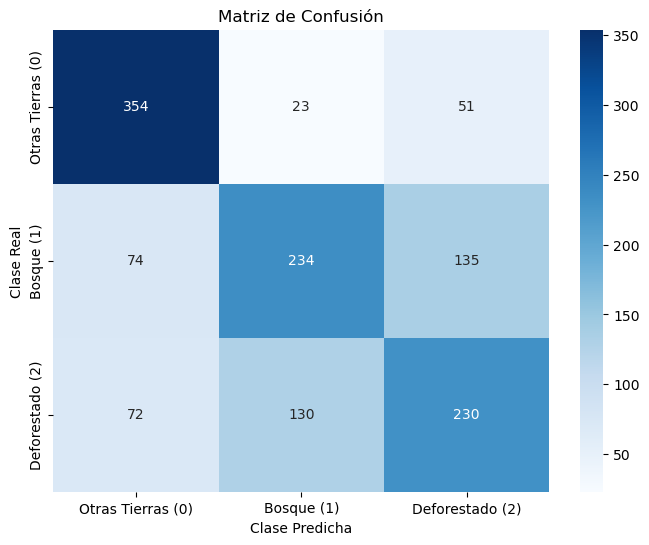

In [ ]:
BANDS = NEW_BAND_NAMES 
CLASS_BAND = 'class'
POINTS_PER_CLASS = 1500
SCALE = 30
MODEL_FILENAME = 'deforestation_model_v3_temporal.pkl'

# 1. Crear datos de entrenamiento y prueba
class_labels_image = label_image.select('constant').rename(CLASS_BAND)

# *** LA CORRECCIÓN ESTÁ AQUÍ ***
# Pasamos la imagen `final_features` que SÍ CONTIENE 'NDVI_diff'
training_gee, testing_gee = create_training_data(
    feature_image=final_features,
    label_image=class_labels_image,
    aoi=cuenca_aoi,
    num_points=POINTS_PER_CLASS,
    scale=SCALE,
    class_band=CLASS_BAND
)

# 2. Preparar los datos para scikit-learn
# Usamos la lista de bandas correcta que coincide con la imagen
X_train, y_train, X_test, y_test, train_df, test_df = prepare_sklearn_data(
    training_gee=training_gee,
    testing_gee=testing_gee,
    features=BANDS,
    target=CLASS_BAND
)

# 3. Entrenar y evaluar el modelo
trained_model = train_and_evaluate_model(X_train, y_train, X_test, y_test)

# 4. Guardar los artefactos finales
save_artifacts(trained_model, train_df, test_df, MODEL_FILENAME)